# 05 · Validación y evaluación: métricas, umbral, costos y calibración

**Edición docente · 8 de octubre de 2026 · Modelos Predictivos en Negocios**

**Unidad 3 · Semanas 7–10 · RA2–RA3 (CE 2.4, 3.1–3.2) · 180 minutos.**
Con PulpaLenga seleccionarás modelos con validación cruzada, ajustarás hiperparámetros sin tocar la prueba, fijarás el umbral por costo en validación, revisarás calibración y evaluarás una sola vez. Cerrarás con fraude desbalanceado y con el laboratorio institucional de la semana 8.

**Cómo trabajar:** ejecuta desde la primera celda. Antes de mover un control, escribe qué esperas que ocurra;
después compara y justifica la diferencia. Los casos son docentes: FinCordillera, QuillayMarket y PulpaLenga son
empresas ficticias con datos simulados del repositorio; las simulaciones adicionales se identifican como tales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten leer los
resultados sin ejecutar. Cada función interactiva también puede llamarse directamente con argumentos.

[Guía maestra](../guia_maestra_mpn.html) · [Manual científico](../material_propio/MPN_manual_cientifico.pdf) ·
[Cobertura curricular](../COBERTURA.md)

### Antes de ejecutar

Núcleo · 90–120 min orientativos.

**Objetivo:** Seleccionar modelo y umbral sin reutilizar la prueba para decidir.

**Preparación:** Módulos 02–04; costos de falsos positivos y negativos.

**Ejemplo de referencia:** PulpaLenga: fijar un umbral con predicciones fuera de pliegue y evaluar al final.

**Práctica:** Cambiar costos y revisar calibración; distinguir ordenamiento de calidad probabilística.

**Criterio de logro:** Documentar selección, datos reservados y costo; no inferir calibración por coincidencia de umbrales.

[Guía y secuencia](../guia_maestra_mpn.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/MPN_manual_cientifico.html#sec-validacion)

In [1]:
from pathlib import Path
import sys
import warnings
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "_transversal" / "datos").is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "03_Modelos_Predictivos_Negocios"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
import mpn_recursos as mr
from mpn_recursos import pregunta, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .18, "font.size": 10})
pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format",
              lambda v: f"{v:,.0f}" if abs(v) >= 1e4 or float(v).is_integer() else f"{v:,.3f}")
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · semilla {SEMILLA}")

Python 3.12.13 · pandas 3.0.6 · semilla 2026


<a id="diseno"></a>

## Diseño de la evaluación: qué datos responden qué pregunta

| Conjunto | Uso en este notebook |
|---|---|
| Entrenamiento (60%) | Ajustar modelos; validación cruzada interna para elegir variables e hiperparámetros |
| Validación (20%) | Elegir umbral por costo, revisar calibración y comparar con reglas simples |
| Prueba (20%) | Una sola evaluación final, con modelo, variables, umbral y costos congelados |

Un error frecuente es elegir el umbral o comparar modelos **con la prueba**: el costo informado resulta
optimista. Aquí cada decisión usa el conjunto que le corresponde.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

calidad = mr.celulosa_calidad()
X = mr.desvios_pulpa(calidad)
y = calidad["defecto"]
crudas = ["temperatura_coccion_c", "presion_digestor_bar", "tiempo_coccion_min", "concentracion_alcali_pct",
          "humedad_madera_pct", "velocidad_linea_m_min"]
desvios = [c for c in X.columns if c.startswith("desv_")] + ["humedad_madera_pct", "velocidad_linea_m_min"]
Xe, Xv, Xt, ye, yv, yt = mr.particion_tres(X, y)
cv = StratifiedKFold(5, shuffle=True, random_state=SEMILLA)
print(f"Tasa de defecto: {y.mean():.1%} · entrenamiento {len(ye)} · validación {len(yv)} · prueba {len(yt)}")

Tasa de defecto: 16.3% · entrenamiento 570 · validación 190 · prueba 190


<a id="cv"></a>

## Validación cruzada: comparar especificaciones con su variabilidad

En $k$ pliegues, cada observación de entrenamiento se usa $k-1$ veces para ajustar y una para evaluar. Se informa
la **media y la desviación estándar** entre pliegues: una diferencia menor que esa variabilidad no justifica preferir
un modelo. Se comparan tres especificaciones. La logística con variables crudas supone efectos monótonos; las
variables de **desvío respecto del óptimo** del proceso (por ejemplo, $|T-168|$) incorporan conocimiento del dominio:
tanto el exceso como el defecto de temperatura generan riesgo.

In [3]:
especificaciones = {
    "Logística · variables crudas": (Pipeline([("escalar", StandardScaler()), ("modelo", LogisticRegression(max_iter=2000))]), crudas),
    "Logística · desvíos del óptimo": (Pipeline([("escalar", StandardScaler()), ("modelo", LogisticRegression(max_iter=2000))]), desvios),
    "Bosque · variables crudas": (RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=SEMILLA, n_jobs=1), crudas)}
filas = []
for nombre, (modelo, columnas) in especificaciones.items():
    r = cross_validate(modelo, Xe[columnas], ye, cv=cv, scoring=["roc_auc", "average_precision"])
    filas.append({"especificación": nombre, "AUC media": r["test_roc_auc"].mean(), "AUC desv.": r["test_roc_auc"].std(ddof=1),
                  "AP media": r["test_average_precision"].mean(), "AP desv.": r["test_average_precision"].std(ddof=1)})
tabla_cv = pd.DataFrame(filas).set_index("especificación")
display(tabla_cv)

,AUC media,AUC desv.,AP media,AP desv.
especificación,,,,
Logística · variables crudas,0.483,0.096,0.210,0.026
Logística · desvíos del óptimo,0.709,0.124,0.407,0.153
Bosque · variables crudas,0.677,0.090,0.322,0.121


**Lectura.** Con variables crudas, la logística no puede representar una relación en forma de «U» y queda muy
por debajo del bosque. Con los desvíos, un modelo simple e interpretable alcanza al bosque; la diferencia entre ambos es
menor que la variabilidad entre pliegues, de modo que la interpretabilidad decide. **La ingeniería de variables guiada por el proceso valió más que cambiar de
algoritmo.** Se continúa con la logística de desvíos.

<a id="hiperparametros"></a>

## Hiperparámetros con búsqueda en grilla y curva de complejidad

Los hiperparámetros se eligen con validación cruzada **dentro de entrenamiento**. Para la logística se busca la
fuerza de regularización $C$ (inversa de la penalización) y el peso de clases. El control muestra, para un árbol,
cómo cambia el desempeño de entrenamiento y de validación cruzada al aumentar la profundidad.

In [4]:
grilla = GridSearchCV(Pipeline([("escalar", StandardScaler()), ("modelo", LogisticRegression(max_iter=2000))]),
                      {"modelo__C": [.01, .1, 1, 10], "modelo__class_weight": [None, "balanced"]},
                      scoring="average_precision", cv=cv, n_jobs=1).fit(Xe[desvios], ye)
display(pd.DataFrame(grilla.cv_results_)[["param_modelo__C", "param_modelo__class_weight", "mean_test_score",
                                          "std_test_score"]].sort_values("mean_test_score", ascending=False).head(6))
modelo_final = grilla.best_estimator_
print("Mejor configuración:", grilla.best_params_)

def explorar_complejidad(profundidad=4):
    r = cross_validate(DecisionTreeClassifier(max_depth=profundidad, random_state=SEMILLA), Xe[desvios], ye, cv=cv,
                       scoring="average_precision", return_train_score=True)
    valores = pd.Series({"AP entrenamiento": r["train_score"].mean(), "AP validación cruzada": r["test_score"].mean(),
                         "brecha": r["train_score"].mean() - r["test_score"].mean()})
    display(valores.to_frame(f"árbol · profundidad {profundidad}"))
    return valores

complejidad_base = explorar_complejidad()
widgets.interact(explorar_complejidad, profundidad=widgets.IntSlider(value=4, min=1, max=15, description="profundidad"));

,param_modelo__C,param_modelo__class_weight,mean_test_score,std_test_score
2,0.100,NaN,0.409,0.139
4,1,NaN,0.407,0.137
6,10,NaN,0.407,0.137
0,0.010,NaN,0.406,0.145
1,0.010,balanced,0.404,0.146
5,1,balanced,0.404,0.137


Mejor configuración: {'modelo__C': 0.1, 'modelo__class_weight': None}


,árbol · profundidad 4
AP entrenamiento,0.570
AP validación cruzada,0.237
brecha,0.333


interactive(children=(IntSlider(value=4, description='profundidad', max=15, min=1), Output()), _dom_classes=('…

<a id="matriz"></a>

## Matriz de confusión y el «modelo perezoso»

Con el modelo elegido se calculan probabilidades de validación. Con el umbral convencional 0,5 se obtiene una
matriz de confusión; se compara con un modelo que **nunca** predice defecto: su accuracy es alta y su recall es cero.

,"modelo · umbral 0,5",nunca predice defecto
TN,157,159
FP,2,0
FN,27,31
TP,4,0
accuracy,0.847,0.837
precision,0.667,0
recall,0.129,0
F1,0.216,0
costo_medio,0.721,0.816


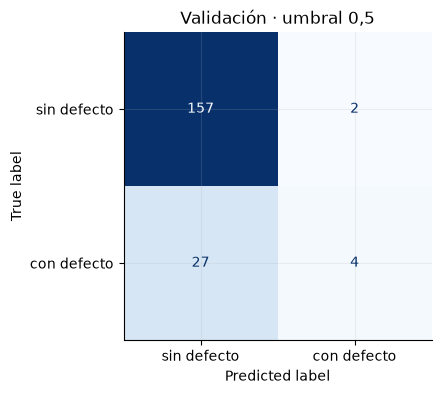

In [5]:
p_val = modelo_final.predict_proba(Xv[desvios])[:, 1]
en_05 = mr.metricas_umbral(yv, p_val, .5)
perezoso = mr.metricas_umbral(yv, np.zeros(len(yv)), .5)
display(pd.DataFrame({"modelo · umbral 0,5": en_05, "nunca predice defecto": perezoso}).drop(index="umbral"))
ConfusionMatrixDisplay(confusion_matrix(yv, p_val >= .5), display_labels=["sin defecto", "con defecto"]).plot(cmap="Blues", colorbar=False)
plt.title("Validación · umbral 0,5"); plt.show()

<a id="curvas"></a>

## Curvas ROC y precisión–recall

La curva ROC grafica tasa de verdaderos positivos frente a tasa de falsos positivos para todos los umbrales; la
curva precisión–recall se concentra en la clase positiva y es más informativa cuando el evento es poco frecuente.
La referencia de la ROC es la diagonal (AUC = 0,5); la de la curva PR es la prevalencia.

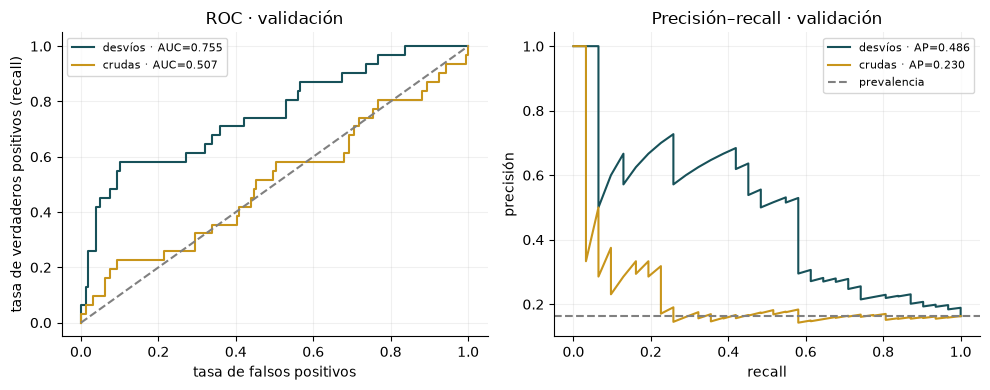

,logística de desvíos · validación
KS,0.480
AUC,0.755
Gini,0.509


In [6]:
logistica_cruda = Pipeline([("escalar", StandardScaler()), ("modelo", LogisticRegression(max_iter=2000))]).fit(Xe[crudas], ye)
p_val_cruda = logistica_cruda.predict_proba(Xv[crudas])[:, 1]
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
for nombre, p, color in [("desvíos", p_val, "#175159"), ("crudas", p_val_cruda, "#c8951b")]:
    fpr, tpr, _ = roc_curve(yv, p); prec, rec, _ = precision_recall_curve(yv, p)
    ejes[0].plot(fpr, tpr, color=color, label=f"{nombre} · AUC={roc_auc_score(yv, p):.3f}")
    ejes[1].plot(rec, prec, color=color, label=f"{nombre} · AP={average_precision_score(yv, p):.3f}")
ejes[0].plot([0, 1], [0, 1], ls="--", color="grey"); ejes[1].axhline(yv.mean(), ls="--", color="grey", label="prevalencia")
ejes[0].set(xlabel="tasa de falsos positivos", ylabel="tasa de verdaderos positivos (recall)", title="ROC · validación")
ejes[1].set(xlabel="recall", ylabel="precisión", title="Precisión–recall · validación")
for e in ejes: e.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.Series(mr.ks_gini(yv, p_val)).to_frame("logística de desvíos · validación"))

<a id="umbral-costo"></a>

## Umbral por costo: la decisión que no toma el algoritmo

El algoritmo **ordena** lotes por riesgo; dónde cortar es una decisión de la jefatura de calidad. Supuestos del caso
(editables): un falso negativo —lote defectuoso despachado— cuesta 800 mil CLP en reclamo, devolución y reputación;
un falso positivo —lote bueno inspeccionado— cuesta 90 mil CLP. Si las probabilidades estuvieran **calibradas**, la
regla de Bayes inspecciona cuando $p\cdot c_{FN} > (1-p)\cdot c_{FP}$, es decir, cuando

$$p > t^* = \frac{c_{FP}}{c_{FP}+c_{FN}} = \frac{90}{890} \approx 0{,}10.$$

En la práctica se busca el umbral de menor costo medio **en validación** y se contrasta con $t^*$.

Umbral de menor costo en validación: 0.11 · umbral teórico con calibración: 0.101


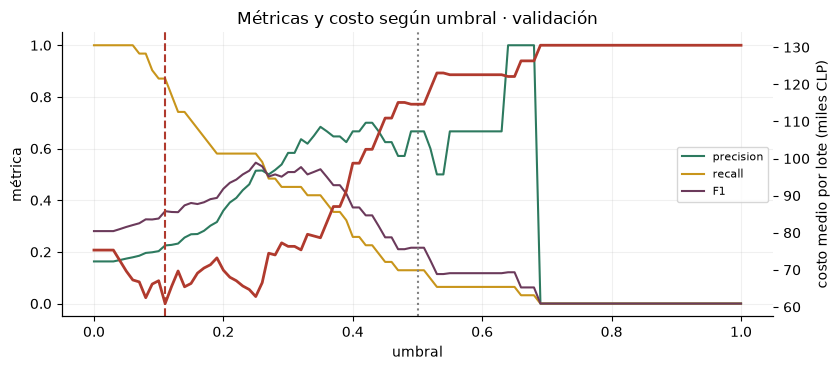

,validación
umbral,0.500
TN,157
FP,2
FN,27
TP,4
accuracy,0.847
precision,0.667
recall,0.129
F1,0.216
costo_medio,114.632


interactive(children=(FloatSlider(value=0.5, description='umbral', max=1.0, step=0.01), IntSlider(value=800, d…

In [7]:
COSTO_FN, COSTO_FP = 800, 90           # miles de CLP, supuestos del caso
tabla = mr.tabla_umbrales(yv, p_val, c_fn=COSTO_FN, c_fp=COSTO_FP)
umbral_costo = float(tabla.loc[tabla["costo_medio"].idxmin(), "umbral"])
t_bayes = mr.umbral_bayes(COSTO_FN, COSTO_FP)
print(f"Umbral de menor costo en validación: {umbral_costo:.2f} · umbral teórico con calibración: {t_bayes:.3f}")
fig, ax = plt.subplots(figsize=(8.5, 3.8))
dentro = tabla[(tabla["umbral"] >= 0) & (tabla["umbral"] <= 1)]
for col, color in [("precision", "#2d7a5f"), ("recall", "#c8951b"), ("F1", "#6b3a5b")]:
    ax.plot(dentro["umbral"], dentro[col], label=col, color=color)
ax2 = ax.twinx(); ax2.plot(dentro["umbral"], dentro["costo_medio"], color="#b03a2e", lw=2, label="costo medio")
ax2.set_ylabel("costo medio por lote (miles CLP)"); ax2.grid(False)
ax.axvline(umbral_costo, color="#b03a2e", ls="--"); ax.axvline(.5, color="grey", ls=":")
ax.set(xlabel="umbral", ylabel="métrica", title="Métricas y costo según umbral · validación"); ax.legend(loc="center right", fontsize=8)
plt.tight_layout(); plt.show()

def explorar_umbral(umbral=.5, costo_fn_miles=800, costo_fp_miles=90):
    m = mr.metricas_umbral(yv, p_val, umbral, c_fn=costo_fn_miles, c_fp=costo_fp_miles)
    m["costo_total_miles"] = m["costo_medio"] * len(yv)
    m["umbral_bayes"] = mr.umbral_bayes(costo_fn_miles, costo_fp_miles)
    display(pd.Series(m).to_frame("validación"))
    return m

umbral_base = explorar_umbral()
widgets.interact(explorar_umbral, umbral=widgets.FloatSlider(value=.5, min=0, max=1, step=.01),
                 costo_fn_miles=widgets.IntSlider(value=800, min=50, max=2000, step=50, description="costo FN"),
                 costo_fp_miles=widgets.IntSlider(value=90, min=10, max=500, step=10, description="costo FP"));

**Lectura.** Como un defecto despachado cuesta casi nueve veces más que una inspección, conviene un umbral muy
inferior a 0,5. Si sube el costo de detener la línea, el umbral óptimo se mueve **sin reentrenar** el modelo:
entrenar es trabajo del analista; fijar el punto de corte es una decisión de gestión con supuestos declarados.

**Estabilidad del umbral.** La validación tiene solo 31 lotes defectuosos: el mínimo de la curva de costo depende
de unos pocos casos con probabilidad baja. Una estimación más estable usa predicciones **fuera de pliegue** en
entrenamiento + validación (cada lote se predice con un modelo que no lo vio) y busca allí el menor costo. También
es legítimo fijar de antemano la regla teórica $t^*$, que solo depende de los costos.

In [8]:
X_desarrollo = pd.concat([Xe, Xv]); y_desarrollo = pd.concat([ye, yv])
p_oof = cross_val_predict(grilla.best_estimator_, X_desarrollo[desvios], y_desarrollo, cv=cv, method="predict_proba")[:, 1]
tabla_oof = mr.tabla_umbrales(y_desarrollo, p_oof, c_fn=COSTO_FN, c_fp=COSTO_FP)
umbral_oof = float(tabla_oof.loc[tabla_oof["costo_medio"].idxmin(), "umbral"])
casi_optimos = tabla_oof[(tabla_oof["costo_medio"] <= tabla_oof["costo_medio"].min() * 1.05)
                         & tabla_oof["umbral"].between(0, 1)]["umbral"]
display(pd.Series({"umbral · validación (31 defectos)": umbral_costo,
                   f"umbral · fuera de pliegue ({int(y_desarrollo.sum())} defectos)": umbral_oof,
                   "umbral teórico t*": t_bayes,
                   "rango con costo a 5% del mínimo (fuera de pliegue)": f"{casi_optimos.min():.2f}–{casi_optimos.max():.2f}"}).to_frame("valor"))

,valor
umbral · validación (31 defectos),0.110
umbral · fuera de pliegue (124 defectos),0.080
umbral teórico t*,0.101
rango con costo a 5% del mínimo (fuera de pliegue),0.07–0.10


<a id="calibracion"></a>

## Calibración: ¿una probabilidad de 0,3 significa 30%?

Un modelo está calibrado si, entre los casos con probabilidad estimada cercana a $p$, la frecuencia observada del
evento es cercana a $p$. El **diagrama de confiabilidad** agrupa probabilidades y compara con frecuencias; el
**puntaje de Brier** $\frac1n\sum(p_i-y_i)^2$ resume la calidad probabilística. La regla $t^*$ solo es óptima con
probabilidades calibradas. La recalibración (por ejemplo, de Platt) se ajusta con validación cruzada en entrenamiento.

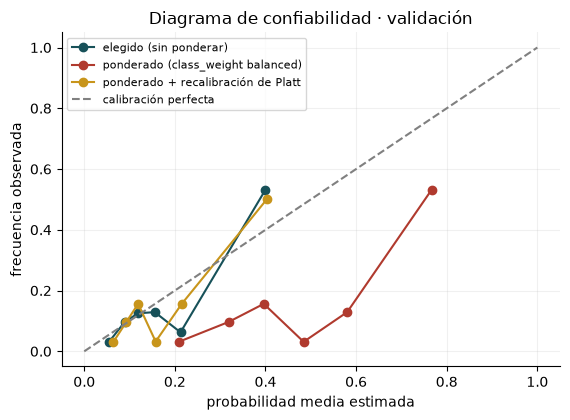

,Brier,AUC,probabilidad media,tasa observada
elegido (sin ponderar),0.113,0.755,0.172,0.163
ponderado (class_weight balanced),0.206,0.755,0.459,0.163
ponderado + recalibración de Platt,0.113,0.755,0.176,0.163


In [9]:
C_elegido = grilla.best_params_["modelo__C"]
def logistica_desvios(peso):
    return Pipeline([("escalar", StandardScaler()),
                     ("modelo", LogisticRegression(max_iter=2000, C=C_elegido, class_weight=peso))])
ponderado = logistica_desvios("balanced").fit(Xe[desvios], ye)
recalibrado = CalibratedClassifierCV(logistica_desvios("balanced"), method="sigmoid", cv=cv).fit(Xe[desvios], ye)
probabilidades = {"elegido (sin ponderar)": p_val,
                  "ponderado (class_weight balanced)": ponderado.predict_proba(Xv[desvios])[:, 1],
                  "ponderado + recalibración de Platt": recalibrado.predict_proba(Xv[desvios])[:, 1]}
fig, ax = plt.subplots(figsize=(5.8, 4.3))
for (nombre, p), color in zip(probabilidades.items(), ["#175159", "#b03a2e", "#c8951b"]):
    frec, media = calibration_curve(yv, p, n_bins=6, strategy="quantile")
    ax.plot(media, frec, marker="o", color=color, label=nombre)
ax.plot([0, 1], [0, 1], ls="--", color="grey", label="calibración perfecta")
ax.set(xlabel="probabilidad media estimada", ylabel="frecuencia observada", title="Diagrama de confiabilidad · validación")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
calibracion = pd.DataFrame({n: {"Brier": mr.brier(yv, p), "AUC": roc_auc_score(yv, p),
                                "probabilidad media": float(np.mean(p)), "tasa observada": float(yv.mean())}
                            for n, p in probabilidades.items()}).T
display(calibracion)

**Lectura.** En este caso, la probabilidad media del modelo sin ponderar es cercana a la tasa observada; esa coincidencia global no demuestra calibración en todos los rangos. La ponderación de clases puede modificar intercepto, coeficientes y orden, especialmente con regularización o especificación imperfecta. Aquí AUC cambia poco, pero no es una garantía general. La recalibración de Platt busca mejorar la escala probabilística; su efecto se comprueba con Brier y diagrama de confiabilidad. El ensamble de calibración cruzada puede cambiar el orden. No afirmar que siempre devuelve probabilidades correctas ni que necesariamente mejora todos los grupos.

<a id="test-final"></a>

## Evaluación final en prueba, con todo congelado

Modelo (logística de desvíos), hiperparámetros y umbrales quedan fijos. Se informan las tres reglas de umbral
definidas antes de mirar la prueba y se comparan con umbral 0,5, inspeccionar todo e inspeccionar nada.

In [10]:
p_prueba = modelo_final.predict_proba(Xt[desvios])[:, 1]
politicas = {"modelo · umbral de validación": mr.metricas_umbral(yt, p_prueba, umbral_costo, COSTO_FN, COSTO_FP),
             "modelo · umbral fuera de pliegue": mr.metricas_umbral(yt, p_prueba, umbral_oof, COSTO_FN, COSTO_FP),
             "modelo · umbral teórico t*": mr.metricas_umbral(yt, p_prueba, t_bayes, COSTO_FN, COSTO_FP),
             "modelo · umbral 0,5": mr.metricas_umbral(yt, p_prueba, .5, COSTO_FN, COSTO_FP),
             "inspeccionar todo": mr.metricas_umbral(yt, np.ones(len(yt)), .5, COSTO_FN, COSTO_FP),
             "no inspeccionar nada": mr.metricas_umbral(yt, np.zeros(len(yt)), .5, COSTO_FN, COSTO_FP)}
final = pd.DataFrame(politicas).T
final["costo_total_miles"] = final["costo_medio"] * len(yt)
display(final[["umbral", "TP", "FN", "FP", "TN", "recall", "precision", "costo_total_miles"]])
display(pd.Series({"AUC prueba": roc_auc_score(yt, p_prueba), "AP prueba": average_precision_score(yt, p_prueba)}).to_frame("valor"))
print("Ningún parámetro se modifica después de observar estos resultados.")

,umbral,TP,FN,FP,TN,recall,precision,costo_total_miles
modelo · umbral de validación,0.110,26,5,86,73,0.839,0.232,"11,740"
modelo · umbral fuera de pliegue,0.080,31,0,116,43,1,0.211,"10,440"
modelo · umbral teórico t*,0.101,28,3,91,68,0.903,0.235,"10,590"
"modelo · umbral 0,5",0.500,3,28,2,157,0.097,0.600,"22,580"
inspeccionar todo,0.500,31,0,159,0,1,0.163,"14,310"
no inspeccionar nada,0.500,0,31,0,159,0,0,"24,800"


,valor
AUC prueba,0.763
AP prueba,0.400


Ningún parámetro se modifica después de observar estos resultados.


**Lectura.** Los tres umbrales —validación, fuera de pliegue y $t^*$— quedan cerca de 0,10, pero el de validación
descansa en solo 31 defectos y podría alejarse en otra muestra; por eso conviene preferir las reglas estables: la cercanía de umbrales no demuestra calibración. La calibración requiere evaluar probabilidades frente a frecuencias y su incertidumbre en datos independientes. Con ellas, el costo en prueba baja de forma
clara frente a 0,5, a no inspeccionar y a inspeccionar todo. El valor del modelo no está en «acertar» más, sino en
inspeccionar menos lotes buenos sin dejar pasar defectos. La decisión final compara ese ahorro con el costo de
operar y monitorear el modelo: esa discusión, con cifras y supuestos, es el producto de la evaluación.

<a id="desbalance"></a>

## Evento raro: fraude en FinCordillera y la incertidumbre de pocas observaciones

Con 2,5% de fraudes (30 casos en 1.200), predecir «nunca fraude» logra 97,5% de accuracy. Con tan pocos positivos,
una partición de prueba tendría unos seis fraudes: cualquier métrica sería muy inestable. Se usan predicciones
**fuera de pliegue** (validación cruzada) para todos los casos y un **bootstrap** para estimar la incertidumbre de AP.

In [11]:
fraude = mr.fincordillera_transacciones()
Xf = fraude.drop(columns=["transaccion_id", "fraude"]); yf = fraude["fraude"]
cv_f = StratifiedKFold(5, shuffle=True, random_state=SEMILLA)
resultado_fraude = {}
for nombre, peso in [("sin ponderar", None), ("class_weight balanced", "balanced")]:
    m = Pipeline([("escalar", StandardScaler()), ("modelo", LogisticRegression(max_iter=2000, class_weight=peso))])
    p_oof = cross_val_predict(m, Xf, yf, cv=cv_f, method="predict_proba")[:, 1]
    g = np.random.default_rng(SEMILLA)
    ap_boot = []
    for _ in range(300):
        i = g.integers(0, len(yf), len(yf))
        if yf.iloc[i].sum() > 0:
            ap_boot.append(average_precision_score(yf.iloc[i], p_oof[i]))
    resultado_fraude[nombre] = {"AUC": roc_auc_score(yf, p_oof), "AP": average_precision_score(yf, p_oof),
                                "AP IC90 inf": np.quantile(ap_boot, .05), "AP IC90 sup": np.quantile(ap_boot, .95)}
resultado_fraude = pd.DataFrame(resultado_fraude).T
resultado_fraude["prevalencia (AP de referencia)"] = yf.mean()
display(resultado_fraude)
print(f"Accuracy de «nunca fraude»: {1 - yf.mean():.1%}")

,AUC,AP,AP IC90 inf,AP IC90 sup,prevalencia (AP de referencia)
sin ponderar,0.805,0.110,0.062,0.214,0.025
class_weight balanced,0.796,0.109,0.061,0.200,0.025


Accuracy de «nunca fraude»: 97.5%


**Lectura.** El modelo multiplica la precisión promedio respecto de la prevalencia, pero el intervalo bootstrap es
amplio: con 30 fraudes no se puede afirmar un desempeño preciso. Antes de prometer una tasa de detección se
necesitan más casos etiquetados, variables de comportamiento (velocidad de transacciones, dispositivo, comercio) y
una evaluación temporal. Ponderar clases cambia probabilidades y umbrales, no crea información nueva.

<a id="laboratorio-s8"></a>

## Laboratorio de la semana 8: lectura crítica de métricas

Una tabla breve de quince casos ficticios entrega ventas reales y predichas, y abandono real y predicho. Se
calculan sus métricas y se agrega una lectura que las tablas suelen omitir: el **sesgo** de las predicciones de
ventas.

In [12]:
s8 = pd.DataFrame({"ventas_reales": [95, 140, 185, 230, 260, 175, 210, 255, 300, 340, 380, 410, 445, 470, 520],
                   "ventas_predichas": [88, 121, 168, 199, 236, 160, 184, 226, 271, 301, 345, 368, 402, 431, 468],
                   "churn_real": [1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1],
                   "churn_predicho": [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]})
reg_s8 = mr.metricas_regresion(s8["ventas_reales"], s8["ventas_predichas"])
cla_s8 = mr.metricas_umbral(s8["churn_real"], s8["churn_predicho"], .5)
display(pd.Series(reg_s8).to_frame("ventas"))
display(pd.Series(cla_s8).drop("costo_medio").to_frame("abandono"))
print(f"Predicciones por debajo del valor real: {(s8.ventas_predichas < s8.ventas_reales).sum()} de {len(s8)}")

,ventas
MAE,29.800
RMSE,32.045
R2,0.933
sesgo_medio,-29.800
MAPE_%,10.248


,abandono
umbral,0.500
TN,8
FP,0
FN,5
TP,2
accuracy,0.667
precision,1
recall,0.286
F1,0.444


Predicciones por debajo del valor real: 15 de 15


**Lectura.** El $R^2$ es alto, pero **todas** las predicciones de ventas están por debajo del valor real: el modelo
tiene un sesgo sistemático que llevaría a comprar menos inventario del necesario. En abandono, la precisión es
perfecta y el recall bajo: el modelo es muy conservador. Recomendación de mejora: recalibrar el nivel de la
predicción con datos independientes y bajar el umbral de abandono según el costo de cada error. Con quince casos,
cualquier conclusión es preliminar.

### Ejercicios resueltos

1. **Umbral teórico.** Con $c_{FN}=5$ y $c_{FP}=1$, $t^*=1/6\approx0{,}17$. Si el costo del falso positivo se duplica,
   $t^*=2/7\approx0{,}29$.
2. **¿Por qué no elegir el umbral en prueba?** Porque la prueba dejaría de ser independiente: el costo informado sería
   optimista y no habría con qué verificarlo.
3. **AUC alto y Brier malo.** Es posible: el orden es correcto, pero las probabilidades están desplazadas. Se corrige
   con recalibración validada; la preservación del orden depende del procedimiento.
4. **Desviación entre pliegues.** Si dos especificaciones difieren 0,01 en AUC y la desviación entre pliegues es 0,03,
   no hay evidencia suficiente para preferir una por desempeño: decide la interpretabilidad o el costo de operación.

In [13]:
auto_05 = pregunta("El umbral se eligió buscando el menor costo sobre el conjunto de prueba. ¿Qué ocurre con el costo informado?",
                   ["Es una estimación independiente del costo futuro",
                    "Es optimista: la prueba participó en la elección y ya no es independiente",
                    "No cambia nada si la prueba es grande"], 1,
                   "Las decisiones se toman en validación; la prueba se consulta una vez con todo congelado.")
assert tabla_cv.loc["Logística · desvíos del óptimo", "AUC media"] > tabla_cv.loc["Logística · variables crudas", "AUC media"] + .1
assert final.loc["modelo · umbral fuera de pliegue", "costo_total_miles"] < final.loc["modelo · umbral 0,5", "costo_total_miles"]
assert final.loc["modelo · umbral teórico t*", "costo_total_miles"] < final.loc["no inspeccionar nada", "costo_total_miles"]
assert calibracion.loc["ponderado + recalibración de Platt", "Brier"] < calibracion.loc["ponderado (class_weight balanced)", "Brier"]
assert umbral_costo < .5 and abs(t_bayes - 90 / 890) < 1e-12
assert resultado_fraude.loc["sin ponderar", "AP"] > 2 * yf.mean()
assert reg_s8["sesgo_medio"] < 0 and cla_s8["precision"] == 1
print("Comprobaciones del laboratorio 05: OK")

Comprobaciones del laboratorio 05: OK


### Referencias

[scikit-learn: evaluación de modelos](https://scikit-learn.org/stable/modules/model_evaluation.html) ·
[scikit-learn: calibración de probabilidades](https://scikit-learn.org/stable/modules/calibration.html) ·
Elkan, «The Foundations of Cost-Sensitive Learning», *IJCAI* (2001) ·
Saito y Rehmsmeier, «The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary
Classifiers on Imbalanced Datasets», *PLOS ONE* 10(3) (2015).